### **Praktikum 7.4: Surveillance Systems - People Counting dan Tracking**

SURVEILLANCE SYSTEMS: PEOPLE COUNTING AND TRACKING


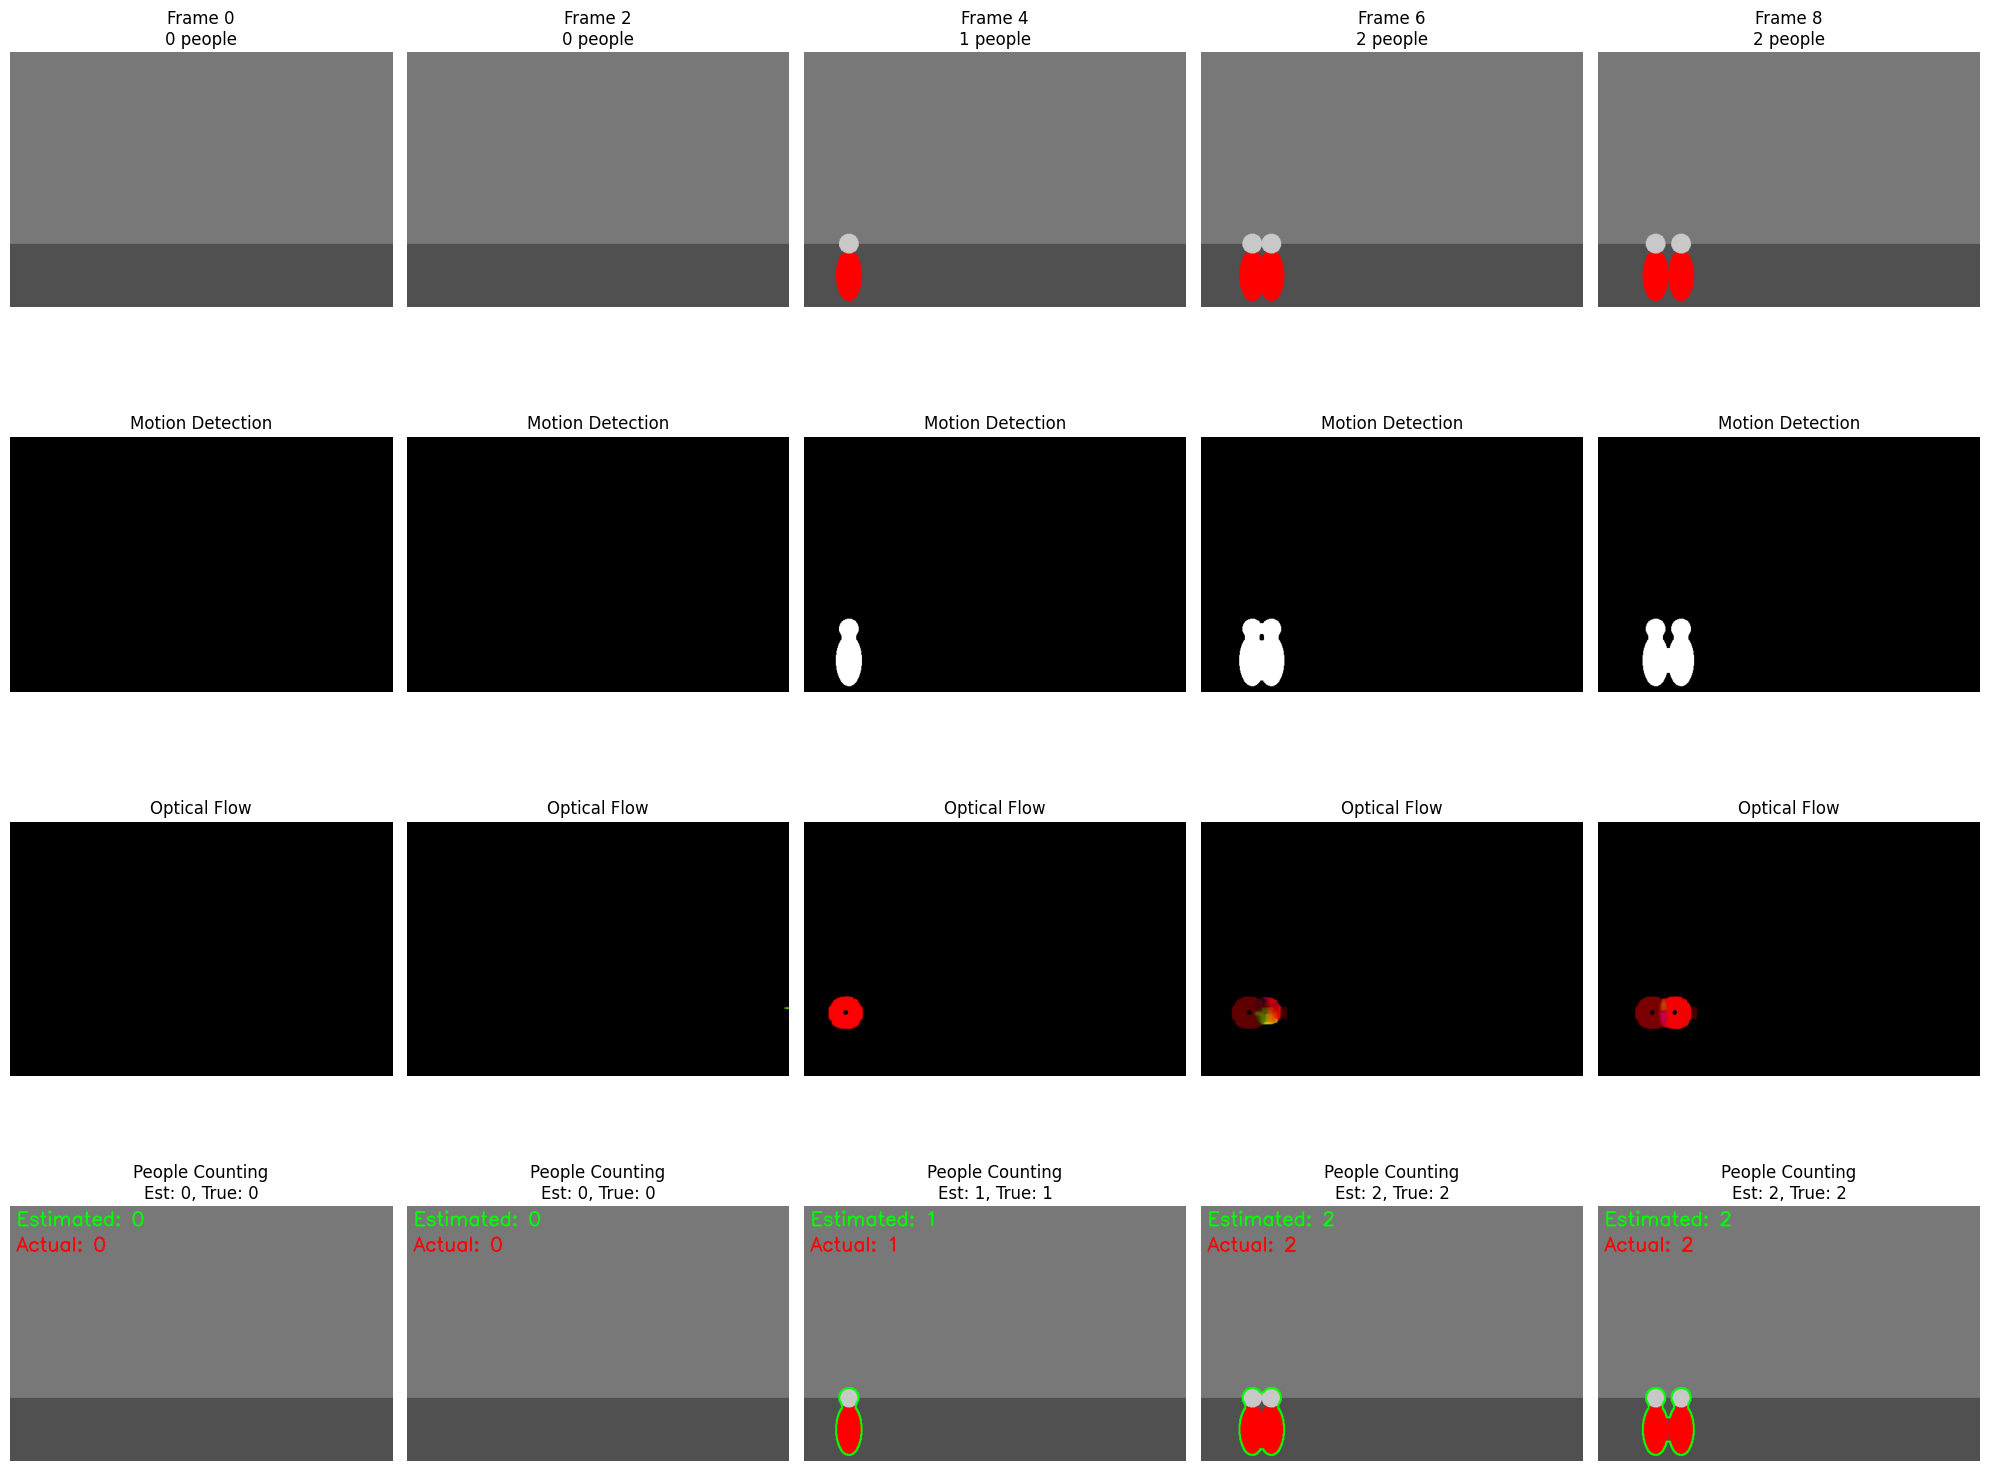

SURVEILLANCE SYSTEM PERFORMANCE ANALYSIS
Counting Accuracy: 1.000 (100.0%)
Mean Absolute Error: 0.00 people per frame
Total People Detected: 12
Total Actual People: 12

SIMPLE TRACKING SIMULATION
------------------------------
Frame 0: 0 people detected
Frame 1: 0 people detected
Frame 2: 0 people detected
Frame 3: 1 people detected
Frame 4: 1 people detected
Frame 5: 1 people detected
Frame 6: 2 people detected
Frame 7: 2 people detected
Frame 8: 2 people detected
Frame 9: 3 people detected


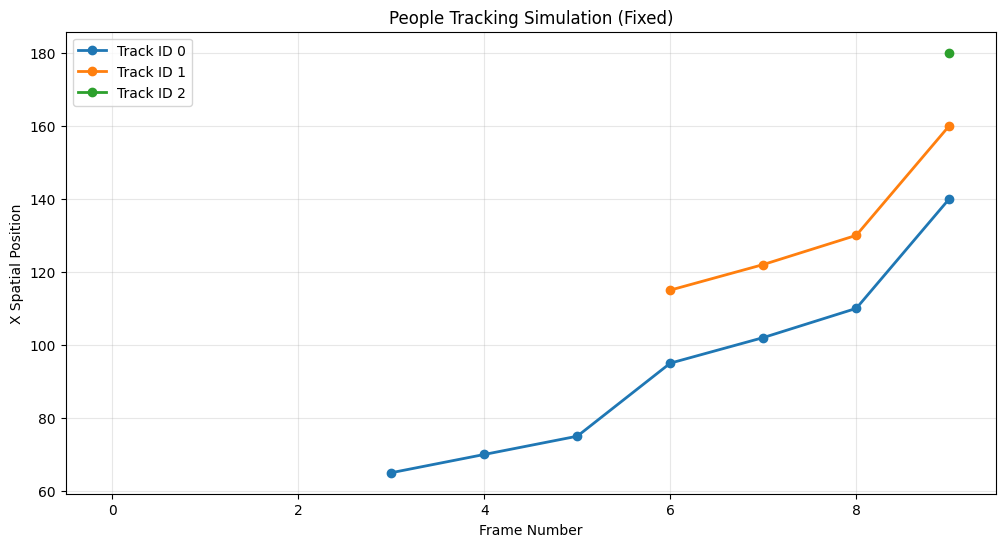

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


def praktikum_7_4():
    print("SURVEILLANCE SYSTEMS: PEOPLE COUNTING AND TRACKING")
    print("=" * 55)

    # 1. Simulate surveillance video frames
    def generate_surveillance_frames(num_frames=10):
        frames = []
        height, width = 400, 600

        # Create background (static scene)
        background = np.ones((height, width, 3), dtype=np.uint8) * 100
        cv2.rectangle(background, (0, 300), (width, height), (80, 80, 80), -1)  # Floor
        cv2.rectangle(background, (0, 0), (width, 300), (120, 120, 120), -1)    # Wall

        for frame_idx in range(num_frames):
            frame = background.copy()

            # Gradually increase people count
            num_people = min(3, frame_idx // 3) 

            people_positions = []
            for i in range(num_people):
                # Each person moves at different speeds
                speed = (i + 1) * 5
                x_pos = 50 + (frame_idx * speed) % (width - 100)
                y_pos = 350  # Fixed height (walking on floor)

                # Draw person as ellipse
                cv2.ellipse(frame, (x_pos, y_pos), (20, 40), 0, 0, 360, (0, 0, 255), -1)  # Body
                cv2.ellipse(frame, (x_pos, y_pos - 50), (15, 15), 0, 0, 360, (200, 200, 200), -1)  # Head

                people_positions.append((x_pos, y_pos))

            frames.append((frame, people_positions))

        return frames

    # 2. Background subtraction for motion detection
    def background_subtraction(frames):
        background = frames[0][0].astype(np.float32)
        results = []
        for frame, _ in frames:
            current_frame = frame.astype(np.float32)
            diff = cv2.absdiff(current_frame, background)
            diff_gray = cv2.cvtColor(diff.astype(np.uint8), cv2.COLOR_BGR2GRAY)
            _, motion_mask = cv2.threshold(diff_gray, 30, 255, cv2.THRESH_BINARY)

            # Morphological operations to clean up noise
            kernel = np.ones((5, 5), np.uint8)
            motion_mask = cv2.morphologyEx(motion_mask, cv2.MORPH_OPEN, kernel)
            motion_mask = cv2.morphologyEx(motion_mask, cv2.MORPH_CLOSE, kernel)
            results.append(motion_mask)
        return results

    # 3. Optical flow based motion detection
    def optical_flow_detection(frames):
        results = []
        prev_gray = None

        for i, (frame, _) in enumerate(frames):
            gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
            if prev_gray is not None:
                flow = cv2.calcOpticalFlowFarneback(prev_gray, gray, None, 0.5, 3, 15, 3, 5, 1.2, 0)
                magnitude, angle = cv2.cartToPolar(flow[..., 0], flow[..., 1])

                hsv = np.zeros_like(frame)
                hsv[..., 0] = angle * 180 / np.pi / 2
                hsv[..., 1] = 255
                hsv[..., 2] = cv2.normalize(magnitude, None, 0, 255, cv2.NORM_MINMAX)

                flow_rgb = cv2.cvtColor(hsv, cv2.COLOR_HSV2BGR)
                results.append(flow_rgb)
            else:
                results.append(np.zeros_like(frame))
            prev_gray = gray
        return results

    # 4. Improved Blob Detection & Estimation Logic
    def blob_detection_people_counting(motion_masks, frames):
        people_counts = []
        detailed_results = []
        centroids_per_frame = []

        # Perkiraan luas rata-rata satu orang objek (tubuh + kepala) di simulasi
        avg_person_area = 3000 

        for i, (motion_mask, (frame, true_positions)) in enumerate(zip(motion_masks, frames)):
            contours, _ = cv2.findContours(motion_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

            people_contours = []
            estimated_count = 0
            frame_centroids = []

            for contour in contours:
                area = cv2.contourArea(contour)
                if area > 500:  # Batas minimum ukuran manusia terpelihara
                    people_contours.append(contour)
                    
                    # Solusi Oklusi: Jika objek berhimpitan, bagi luasnya dengan estimasi luas 1 orang
                    calculated_blobs = max(1, int(np.round(area / avg_person_area)))
                    estimated_count += calculated_blobs

                    # Ambil titik tengah koordinat (Centroid) untuk keperluan tracking
                    M = cv2.moments(contour)
                    if M["m00"] != 0:
                        cX = int(M["m10"] / M["m00"])
                        cY = int(M["m01"] / M["m00"])
                        
                        # Jika terdeteksi seolah ada > 1 orang di kontur yang sama, 
                        # duplikasi centroid dengan sedikit pergeseran spasial agar tracker mendeteksi objek terpisah
                        for b in range(calculated_blobs):
                            frame_centroids.append((cX + (b * 20), cY))

            true_count = len(true_positions)
            result_frame = frame.copy()
            cv2.drawContours(result_frame, people_contours, -1, (0, 255, 0), 2)

            cv2.putText(result_frame, f'Estimated: {estimated_count}', (10, 30),
                        cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
            cv2.putText(result_frame, f'Actual: {true_count}', (10, 70),
                        cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2)

            people_counts.append((estimated_count, true_count))
            detailed_results.append(result_frame)
            centroids_per_frame.append(frame_centroids)

        return people_counts, detailed_results, centroids_per_frame

    # Main Pipeline Execution
    frames = generate_surveillance_frames(10)
    motion_masks = background_subtraction(frames)
    optical_flows = optical_flow_detection(frames)
    people_counts, counting_results, centroids_per_frame = blob_detection_people_counting(motion_masks, frames)

    # Visualization: 4x5 Subplots
    fig, axes = plt.subplots(4, 5, figsize=(20, 16))
    for i in range(5):
        idx = i * 2
        if idx < len(frames):
            axes[0, i].imshow(cv2.cvtColor(frames[idx][0], cv2.COLOR_BGR2RGB))
            axes[0, i].set_title(f'Frame {idx}\n{len(frames[idx][1])} people')
            axes[0, i].axis('off')

            axes[1, i].imshow(motion_masks[idx], cmap='gray')
            axes[1, i].set_title('Motion Detection')
            axes[1, i].axis('off')

            axes[2, i].imshow(cv2.cvtColor(optical_flows[idx], cv2.COLOR_BGR2RGB))
            axes[2, i].set_title('Optical Flow')
            axes[2, i].axis('off')

            axes[3, i].imshow(cv2.cvtColor(counting_results[idx], cv2.COLOR_BGR2RGB))
            est_count, true_count = people_counts[idx]
            axes[3, i].set_title(f'People Counting\nEst: {est_count}, True: {true_count}')
            axes[3, i].axis('off')

    plt.tight_layout()
    plt.show()

    # Print Performance Analysis
    print("SURVEILLANCE SYSTEM PERFORMANCE ANALYSIS")
    print("=" * 50)
    estimated_counts = [est for est, true in people_counts]
    true_counts = [true for est, true in people_counts]

    accuracy = np.mean(np.array(estimated_counts) == np.array(true_counts))
    mae = np.mean(np.abs(np.array(estimated_counts) - np.array(true_counts)))

    print(f"Counting Accuracy: {accuracy:.3f} ({accuracy * 100:.1f}%)")
    print(f"Mean Absolute Error: {mae:.2f} people per frame")
    print(f"Total People Detected: {sum(estimated_counts)}")
    print(f"Total Actual People: {sum(true_counts)}")

    # 5. Fixed Tracking Logic (Proximity Centroid Association)
    print("\nSIMPLE TRACKING SIMULATION")
    print("-" * 30)

    tracks = {}
    next_track_id = 0
    max_distance_threshold = 40  # Toleransi jarak maksimum perpindahan objek per frame

    for frame_idx, frame_centroids in enumerate(centroids_per_frame):
        print(f"Frame {frame_idx}: {len(frame_centroids)} people detected")
        
        if len(frame_centroids) == 0:
            continue

        # Jika dictionary tracks masih kosong, inisialisasi semua centroid pertama sebagai track baru
        if not tracks:
            for pt in frame_centroids:
                tracks[next_track_id] = {'positions': [(frame_idx, pt[0])]}
                next_track_id += 1
        else:
            unmatched_centroids = list(frame_centroids)
            
            # Cari kecocokan untuk track yang sedang aktif di frame sebelumnya
            for track_id, track_info in tracks.items():
                if track_info['positions'][-1][0] == frame_idx - 1:
                    last_x = track_info['positions'][-1][1]
                    
                    if len(unmatched_centroids) > 0:
                        # Cari indeks centroid terdekat berdasarkan posisi X
                        distances = [abs(pt[0] - last_x) for pt in unmatched_centroids]
                        closest_idx = np.argmin(distances)
                        
                        if distances[closest_idx] < max_distance_threshold:
                            track_info['positions'].append((frame_idx, unmatched_centroids[closest_idx][0]))
                            unmatched_centroids.pop(closest_idx)
            
            # Centroid sisa yang tidak cocok dengan track lama didaftarkan sebagai Track Baru (Dinamis)
            for pt in unmatched_centroids:
                tracks[next_track_id] = {'positions': [(frame_idx, pt[0])]}
                next_track_id += 1

    # Display Plot Real Tracking Hasil Perbaikan
    plt.figure(figsize=(12, 6))
    if tracks:
        for track_id, track_info in tracks.items():
            positions = track_info['positions']
            frames_list = [pos[0] for pos in positions]
            x_positions = [pos[1] for pos in positions]
            plt.plot(frames_list, x_positions, marker='o', linewidth=2, label=f'Track ID {track_id}')
        plt.legend(loc='upper left')
    else:
        plt.text(0.5, 0.5, 'No active tracks found', horizontalalignment='center', verticalalignment='center')
        
    plt.xlabel('Frame Number')
    plt.ylabel('X Spatial Position')
    plt.title('People Tracking Simulation (Fixed)')
    plt.grid(True, alpha=0.3)
    plt.xlim(-0.5, 9.5)
    plt.show()

    return people_counts, tracks


# Jalankan fungsi utama
people_counts, tracking_data = praktikum_7_4()